<table align="left">
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fsalekh%2Fcloud-summit-dach-2026%2Fmain%2Fnotebooks%2Fcymbal_brand_campaigns.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Colab Enterprise logo"><br> Open in Colab Enterprise
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://github.com/salekh/cloud-summit-dach-2026">
      <img width="32px" src="https://raw.githubusercontent.com/primer/octicons/refs/heads/main/icons/mark-github-24.svg" alt="GitHub logo"><br> View on GitHub
    </a>
  </td>
</table>

<br/><br/><br/>

# 🎯 From Prompt to Campaign: Building the Next Generation of Brand Storytelling

### Google Cloud DACH AI Summit — Frankfurt 2026

---

**What you'll learn in this session:**

| Step | What We'll Do | Model Used |
|------|--------------|------------|
| 🏗️ **Setup** | Configure GCS buckets & upload brand assets | — |
| 📖 **Brand DNA** | Ingest Cymbal's complete brand design language | — |
| 🎨 **Campaign 1** | Generate a Cymbal Superstore digital ad (guided) | Nano Banana 2 |
| 🏦 **Campaign 2** | Generate a Cymbal Bank campaign (LLM-assisted ideation) | Gemini 3.5 Flash + Nano Banana 2 |
| 💊 **Campaign 3** | Generate a Cymbal Health campaign (your turn!) | Gemini 3.5 Flash + Nano Banana 2 |
| 🌍 **Localization** | Regionalize a campaign for the German market | Gemini 3.5 Flash + Nano Banana 2 |

> **Models:**
> - **Nano Banana 2** (`gemini-3.1-flash-image-preview`) — Native image generation
> - **Gemini 3.5 Flash** (`gemini-3.5-flash`) — Creative ideation & text generation

---

**Brand:** [Cymbal](https://cloud.google.com/) — A Google Cloud demo brand with 9 subsidiaries across Healthcare, Retail, and Financial Services.


## 🛠️ Section 1: Environment Setup & GCS Configuration

Before we generate any campaigns, we need to:
1. **Install** the required Python packages
2. **Authenticate** with Google Cloud
3. **Create GCS buckets** for storing brand inputs and generated outputs
4. **Upload brand assets** (logos, PDFs, design samples) to the input bucket

> 💡 **Why GCS?** The Gemini API can natively reference files stored in Google Cloud Storage via `gs://` URIs. This is the production pattern — your brand assets live in a central bucket, and every campaign generation job references them directly. No local file handling needed.

In [ ]:
# Install dependencies (Colab Enterprise)
# google-cloud-storage and google-auth are pre-installed in Colab Enterprise
%pip install -q google-genai google-cloud-storage Pillow


In [ ]:
# Authentication — auto-detect environment
import sys
import os

def authenticate():
    """Authenticate based on detected environment."""
    # Colab / Colab Enterprise
    try:
        from google.colab import auth
        auth.authenticate_user()
        print("✅ Authenticated via Colab.")
        return
    except ImportError:
        pass

    # Local Jupyter — check for ADC
    adc_path = os.path.expanduser("~/.config/gcloud/application_default_credentials.json")
    if os.path.exists(adc_path):
        print("✅ Using Application Default Credentials (ADC).")
        return

    print("⚠️  No credentials found. Run: gcloud auth application-default login")

authenticate()

In [ ]:
# @title 🔐 Authenticate & Configure Project
# @markdown Fill in your project details below. These fields are interactive in Colab Enterprise.

PROJECT_ID = ""  # @param {type:"string"}
REGION = "europe-west3"  # @param {type:"string"}
AI_REGION = "global"  # @param {type:"string"}

import google.auth
import os
import subprocess

# --- Credentials ---
credentials, auth_project_id = google.auth.default()

# --- Project ID: use form value, else auto-detect ---
if not PROJECT_ID:
    PROJECT_ID = (
        os.environ.get("GOOGLE_CLOUD_PROJECT")
        or os.environ.get("CLOUD_ML_PROJECT_ID")
        or auth_project_id
    )
if not PROJECT_ID:
    try:
        PROJECT_ID = subprocess.check_output(
            ["gcloud", "config", "get-value", "project"],
            stderr=subprocess.DEVNULL
        ).decode().strip()
    except Exception:
        pass

assert PROJECT_ID, "❌ Could not detect project ID. Enter it in the form above."
os.environ["GOOGLE_CLOUD_PROJECT"] = PROJECT_ID
USER_EMAIL = subprocess.check_output(
            ["gcloud", "config", "get-value", "account"],
            stderr=subprocess.DEVNULL
        ).decode().strip()
username_prefix = USER_EMAIL.split("@")[0].replace(".", "-")

print(f"✅ Authenticated as: {USER_EMAIL}")
print(f"📁 Project ID:       {PROJECT_ID}")
print(f"🌍 Region:           {REGION}")
print(f"🤖 AI Region:        {AI_REGION}")
print(f"👤 Username prefix:  {username_prefix}")


In [ ]:
# Cell 1.4 — Create GCS buckets for inputs and outputs
from google.cloud import storage

storage_client = storage.Client(project=PROJECT_ID)

# Define bucket and paths
BUCKET_NAME = f"{username_prefix}"
INPUT_PREFIX = "cloud-summit-dach-2026/genmedia/inputs"
OUTPUT_PREFIX = "cloud-summit-dach-2026/genmedia/outputs"

# Create the bucket if it doesn't exist
try:
    bucket = storage_client.get_bucket(BUCKET_NAME)
    print(f"✅ Bucket gs://{BUCKET_NAME} already exists.")
except Exception:
    bucket = storage_client.create_bucket(BUCKET_NAME, location="US")
    print(f"✅ Created bucket gs://{BUCKET_NAME}")

# Create placeholder objects to "create" the folder structure
for prefix in [INPUT_PREFIX, OUTPUT_PREFIX]:
    blob = bucket.blob(f"{prefix}/")
    if not blob.exists():
        blob.upload_from_string("")
        print(f"   📂 Created folder: gs://{BUCKET_NAME}/{prefix}/")
    else:
        print(f"   📂 Folder exists:  gs://{BUCKET_NAME}/{prefix}/")

print(f"\n🎯 Input path:  gs://{BUCKET_NAME}/{INPUT_PREFIX}/")
print(f"🎯 Output path: gs://{BUCKET_NAME}/{OUTPUT_PREFIX}/")

In [ ]:
# Cell 1.5 — Download brand assets from GitHub and upload to GCS
import requests
from urllib.parse import quote

# Public GitHub repo — raw content URL
GITHUB_RAW = "https://raw.githubusercontent.com/salekh/cloud-summit-dach-2026/main/ingredients/cymbal-design"

# All assets: (github_relative_path, gcs_destination, content_type)
ASSETS = []

# 1. Brand guidelines
ASSETS.append(("cymbal_brand_design_language.md",
               f"{INPUT_PREFIX}/brand_guidelines/cymbal_brand_design_language.md", "text/markdown"))
ASSETS.append(("Cymbal Brand Design Language.pdf",
               f"{INPUT_PREFIX}/brand_guidelines/Cymbal Brand Design Language.pdf", "application/pdf"))

# 2. Logos
for name in ["bank", "direct", "fintech", "health", "insurance",
             "investments", "labs", "shops", "superstore"]:
    ASSETS.append((f"logos/{name}.png", f"{INPUT_PREFIX}/logos/{name}.png", "image/png"))

# 3. Brand samples (01–25)
SAMPLE_NAMES = [
    "01_parent_wordmark", "02_parent_monogram", "03_icon_grid_system",
    "04_shape_library", "05_primary_colors", "06_typography_spec",
    "07_typography_pairings", "08_typography_scale", "09_layout_spacing",
    "10_ui_color_shades", "11_ui_color_application", "12_ui_border_radius",
    "13_parent_wordmark_large", "14_parent_monogram_large",
    "15_logo_monogram_variants", "16_shape_library_full",
    "17_shape_usage_examples", "18_subsidiary_logo_lockups",
    "19_color_palette_subsidiaries", "20_typography_dm_sans",
    "21_subsidiary_ui_color_application", "22_illustration_overview",
    "23_website_application_mockups", "24_photography_hcls",
    "25_photography_retail",
]
for name in SAMPLE_NAMES:
    ASSETS.append((f"brand_samples/{name}.png", f"{INPUT_PREFIX}/brand_samples/{name}.png", "image/png"))

# Download from GitHub → upload to GCS
print(f"📤 Downloading {len(ASSETS)} brand assets from GitHub → GCS...\n")
uploaded, skipped, failed = 0, 0, 0

for github_path, gcs_path, content_type in ASSETS:
    blob = bucket.blob(gcs_path)
    filename = github_path.split("/")[-1]

    if blob.exists():
        print(f"   ⭕ {filename:50s} (already in GCS)")
        skipped += 1
        continue

    url = f"{GITHUB_RAW}/{quote(github_path)}"
    resp = requests.get(url, timeout=120)

    if resp.status_code == 200:
        blob.upload_from_string(resp.content, content_type=content_type)
        size_kb = len(resp.content) / 1024
        print(f"   ✅ {filename:50s} ({size_kb:,.0f} KB)")
        uploaded += 1
    else:
        print(f"   ❌ {filename:50s} (HTTP {resp.status_code})")
        failed += 1

print(f"\n🎉 Done! {uploaded} uploaded, {skipped} already existed, {failed} failed.")


In [ ]:
# Cell 1.6 — Preview brand assets from GCS
from IPython.display import display, Markdown, Image as IPyImage
import io

# Select 5 key brand assets to preview
PREVIEW_ASSETS = [
    (f"{INPUT_PREFIX}/brand_samples/01_parent_wordmark.png", "Cymbal Parent Wordmark"),
    (f"{INPUT_PREFIX}/brand_samples/05_primary_colors.png", "Primary Color Palette"),
    (f"{INPUT_PREFIX}/brand_samples/06_typography_spec.png", "Typography Specification"),
    (f"{INPUT_PREFIX}/logos/superstore.png", "Cymbal Superstore Logo"),
    (f"{INPUT_PREFIX}/brand_samples/18_subsidiary_logo_lockups.png", "Subsidiary Logo Lockups"),
]

print("🖼️ Brand Asset Preview (from GCS)\n")

for gcs_path, title in PREVIEW_ASSETS:
    blob = bucket.blob(gcs_path)
    data = blob.download_as_bytes()
    display(Markdown(f"---\n### {title}"))
    display(Markdown(f"*`gs://{BUCKET_NAME}/{gcs_path}`*"))
    display(IPyImage(data=data))


### 🗂️ GCS Bucket Structure

Here's what our cloud storage now looks like:

```
gs://{username}/cloud-summit-dach-2026/genmedia/
├── inputs/
│   ├── brand_guidelines/
│   │   ├── cymbal_brand_design_language.md
│   │   └── Cymbal Brand Design Language.pdf
│   ├── logos/
│   │   ├── bank.png, health.png, superstore.png, ...
│   └── brand_samples/
│       ├── 01_parent_wordmark.png
│       ├── 02_parent_monogram.png
│       └── ... (25 reference images)
└── outputs/
    └── (generated campaigns will appear here)
```

> 💡 **Why this structure matters:** By organizing brand assets in a central GCS bucket, every team member, pipeline, and API call references the **same source of truth**. When the brand guide updates, you update one bucket — not 50 scripts.

---

## 📖 Section 2: Loading the Cymbal Brand DNA

Great brands aren't built by accident. Every color, typeface, shape, and photograph in a Cymbal campaign follows a precise **Brand Design Language** — a comprehensive rulebook covering:

- 🎨 **Color palettes** — Industry-coded (Blue = Healthcare, Red = Retail, Green = Finance)
- ✒️ **Typography** — DM Sans exclusively, with strict weight/size hierarchies
- 🔶 **Shape system** — 30+ geometric shapes derived from a unified icon grid
- 📷 **Photography principles** — Warm, diverse, naturalistic, with per-industry tonal biases
- 🗓️ **Layout rules** — 12-column grid, generous negative space, arch/semicircle supergraphic

**Our approach:** We'll feed the model *both* the structured text guidelines (for precision) *and* the visual PDF + sample images (for style understanding). This dual-channel approach gives the best brand adherence.

> 🎯 **Best Practice:** Always provide brand guidelines in multiple modalities. Text for rules, images for visual style. Models understand both — leverage it.

In [ ]:
# Cell 2.2 — Load the brand design language from GCS

brand_md_blob = bucket.blob(f"{INPUT_PREFIX}/brand_guidelines/cymbal_brand_design_language.md")
brand_design_language = brand_md_blob.download_as_text()

print(f"📖 Loaded brand design language from GCS: {len(brand_design_language):,} characters")
print(f"   Sections covered: {brand_design_language.count('## ')} major sections")
print(f"   Tables:           {brand_design_language.count('|---')} specification tables")
print(f"\n🔍 Preview (first 500 chars):")
print(brand_design_language[:500])


In [ ]:
# Initialize the Gemini client and define GCS references

from google import genai
from google.genai import types
from PIL import Image
from IPython import display as IPydisplay
import io
import json

# Initialize the GenAI client — using the global endpoint
client = genai.Client(
    vertexai=True,
    project=PROJECT_ID,
    location=AI_REGION,
)

# Model IDs
NANO_BANANA_MODEL = "gemini-3.1-flash-image-preview"  # Nano Banana 2 — image generation
GEMINI_FLASH_MODEL = "gemini-3.5-flash"  # Gemini 3.5 Flash — text/ideation

# GCS URI helpers
def gcs_uri(path: str) -> str:
    """Construct a full GCS URI from a relative path."""
    return f"gs://{BUCKET_NAME}/{path}"

# Define all brand asset GCS URIs
BRAND_ASSETS = {
    # Brand guidelines
    "brand_pdf": gcs_uri(f"{INPUT_PREFIX}/brand_guidelines/Cymbal Brand Design Language.pdf"),
    "brand_md": gcs_uri(f"{INPUT_PREFIX}/brand_guidelines/cymbal_brand_design_language.md"),
    
    # Logos (per sub-brand)
    "logo_superstore": gcs_uri(f"{INPUT_PREFIX}/logos/superstore.png"),
    "logo_bank": gcs_uri(f"{INPUT_PREFIX}/logos/bank.png"),
    "logo_health": gcs_uri(f"{INPUT_PREFIX}/logos/health.png"),
    "logo_shops": gcs_uri(f"{INPUT_PREFIX}/logos/shops.png"),
    "logo_direct": gcs_uri(f"{INPUT_PREFIX}/logos/direct.png"),
    "logo_investments": gcs_uri(f"{INPUT_PREFIX}/logos/investments.png"),
    "logo_insurance": gcs_uri(f"{INPUT_PREFIX}/logos/insurance.png"),
    "logo_labs": gcs_uri(f"{INPUT_PREFIX}/logos/labs.png"),
    "logo_fintech": gcs_uri(f"{INPUT_PREFIX}/logos/fintech.png"),
    
    # Key brand samples
    "sample_wordmark": gcs_uri(f"{INPUT_PREFIX}/brand_samples/01_parent_wordmark.png"),
    "sample_monogram": gcs_uri(f"{INPUT_PREFIX}/brand_samples/02_parent_monogram.png"),
    "sample_shape_library": gcs_uri(f"{INPUT_PREFIX}/brand_samples/04_shape_library.png"),
    "sample_colors": gcs_uri(f"{INPUT_PREFIX}/brand_samples/05_primary_colors.png"),
    "sample_typography": gcs_uri(f"{INPUT_PREFIX}/brand_samples/06_typography_spec.png"),
    "sample_layout": gcs_uri(f"{INPUT_PREFIX}/brand_samples/09_layout_spacing.png"),
}

print("✅ Gemini client initialized (global endpoint)")
print(f"   🎨 Image model:  {NANO_BANANA_MODEL}")
print(f"   💬 Text model:   {GEMINI_FLASH_MODEL}")
print(f"   📁 Brand assets: {len(BRAND_ASSETS)} references loaded")


In [ ]:
# Reusable brand context builder & utility functions

def build_brand_context(sub_brand: str, extra_samples: list[str] | None = None) -> list:
    """
    Build the multimodal brand context payload for a given sub-brand.
    
    This returns a list of content parts that should be prepended to any
    campaign generation prompt. It includes:
    - The brand design language PDF (visual reference)
    - Key visual samples (wordmark, monogram, colors, typography, layout)
    - The specific sub-brand logo
    - The structured text brand guidelines
    
    Args:
        sub_brand: One of 'superstore', 'bank', 'health', 'shops', 'direct',
                   'investments', 'insurance', 'labs', 'fintech'
        extra_samples: Optional list of additional brand sample keys from BRAND_ASSETS
    
    Returns:
        List of content parts for the Gemini API
    """
    parts = []
    
    # 1. Brand design PDF (visual reference)
    parts.append(types.Part.from_uri(
        file_uri=BRAND_ASSETS["brand_pdf"],
        mime_type="application/pdf"
    ))
    
    # 2. Key brand visual samples
    for sample_key in ["sample_wordmark", "sample_monogram", "sample_shape_library",
                       "sample_colors", "sample_typography", "sample_layout"]:
        parts.append(types.Part.from_uri(
            file_uri=BRAND_ASSETS[sample_key],
            mime_type="image/png"
        ))
    
    # 3. Sub-brand specific logo
    logo_key = f"logo_{sub_brand}"
    if logo_key in BRAND_ASSETS:
        parts.append(types.Part.from_uri(
            file_uri=BRAND_ASSETS[logo_key],
            mime_type="image/png"
        ))
    
    # 4. Additional samples if requested
    if extra_samples:
        for sample_key in extra_samples:
            if sample_key in BRAND_ASSETS:
                parts.append(types.Part.from_uri(
                    file_uri=BRAND_ASSETS[sample_key],
                    mime_type="image/png"
                ))
    
    # 5. Structured text guidelines (appended last for recency bias)
    parts.append(types.Part.from_text(
        text=f"""=== CYMBAL BRAND DESIGN LANGUAGE (COMPLETE REFERENCE) ===

{brand_design_language}

=== END OF BRAND GUIDELINES ===

=== IMPORTANT INSTRUCTIONS ===
The brand samples above are REFERENCE MATERIAL showing design specifications.
Do NOT copy layout artifacts such as: rulers, grid lines, column numbers,
measurement marks, dotted guidelines, alignment indicators, or any other
design-system scaffolding. Generate a FINAL, POLISHED campaign image that
NEVER render the Cymbal monogram from text characters. Always use the
provided monogram IMAGE asset as-is. Do not type or draw the monogram.
a customer would see — clean, professional, and free of any design tooling.
=== END OF INSTRUCTIONS ==="""
    ))
    
    return parts


def save_and_display_image(image_data: bytes, filename: str, title: str = "") -> str:
    """
    Save a generated image to GCS and display it inline.
    Uses Colab-native display (PIL images render natively in output cells).
    """
    gcs_path = f"{OUTPUT_PREFIX}/{filename}"
    blob = bucket.blob(gcs_path)
    blob.upload_from_string(image_data, content_type="image/png")
    
    output_uri = f"gs://{BUCKET_NAME}/{gcs_path}"
    
    if title:
        IPydisplay.display(IPydisplay.Markdown(f"### {title}"))
    IPydisplay.display(IPydisplay.Markdown(f"*Saved to:* `{output_uri}`"))
    
    # PIL images display natively in Colab Enterprise output cells
    img = Image.open(io.BytesIO(image_data))
    IPydisplay.display(img)
    
    return output_uri


def generate_campaign_image(
    prompt: str,
    sub_brand: str,
    filename: str,
    title: str = "",
    extra_samples: list[str] | None = None,
    input_image_uri: str | None = None,
    aspect_ratio: str = "3:2",
) -> tuple[str, bytes]:
    """
    End-to-end campaign image generation:
    1. Build brand context
    2. Call Nano Banana 2
    3. Save to GCS
    4. Display inline (Colab-native)
    """
    # Build the content parts
    parts = build_brand_context(sub_brand, extra_samples)
    
    # Add input image if provided (for edit/localization workflows)
    if input_image_uri:
        parts.append(types.Part.from_uri(
            file_uri=input_image_uri,
            mime_type="image/png"
        ))
    
    # Add the campaign prompt
    parts.append(types.Part.from_text(text=prompt))
    
    # Call Nano Banana 2
    response = client.models.generate_content(
        model=NANO_BANANA_MODEL,
        contents=types.Content(
            role="user",
            parts=parts
        ),
        config=types.GenerateContentConfig(
            response_modalities=["IMAGE", "TEXT"],
            image_config=types.ImageConfig(
                aspect_ratio=aspect_ratio,
                image_size="1K",
                output_mime_type="image/png",
            ),
            thinking_config=types.ThinkingConfig(
                thinking_level="MINIMAL",
            ),
        )
    )
    
    # Extract the generated image
    image_data = None
    for part in response.candidates[0].content.parts:
        if part.inline_data and part.inline_data.mime_type.startswith("image/"):
            image_data = part.inline_data.data
            break
    
    if image_data is None:
        print("⚠️ No image was generated. Model response:")
        for part in response.candidates[0].content.parts:
            if part.text:
                print(part.text)
        return None, None
    
    # Save and display
    output_uri = save_and_display_image(image_data, filename, title)
    return output_uri, image_data


print("✅ Utility functions defined:")
print("   🔧 build_brand_context()    — Assemble multimodal brand payload")
print("   💾 save_and_display_image() — Save to GCS + inline display")
print("   🎨 generate_campaign_image()— End-to-end generation pipeline")


### 🎯 Best Practices: Building Your Brand Context

| Approach | What to Include | Why |
|---------|----------------|-----|
| **Text context** | Structured markdown/text brand guidelines | Rules, specs, hex codes, font names — precise & parseable |
| **PDF input** | Original brand guide PDFs | Visual layouts, color swatches, typography samples — the model "sees" the style |
| **Logo images** | Sub-brand specific logo PNGs | Direct visual reference for logo placement |
| **Brand samples** | Key design reference images (wordmark, monogram, colors, shapes) | Teaches the model the visual vocabulary |

> ⚠️ **Token budget tip:** Don't dump your entire 200-page brand bible. Curate the **most relevant** visual references for each campaign type. Our `build_brand_context()` function selects the 6 most impactful brand samples plus the sub-brand logo — a good balance of context richness and efficiency.

> 💡 **Pro tip:** Place the structured text guidelines **last** in the content parts. Language models exhibit recency bias — the last content seen has the strongest influence on generation. By placing precise rules last, you maximize brand adherence.

---

## 🎨 Section 3: Campaign 1 — Cymbal Superstore: "A Warmer Way to Shop"

Our first campaign is a **fully guided example**. We'll walk through every decision:

### Campaign Concept

| Element | Specification |
|---------|---------------|
| **Brand** | Cymbal Superstore (Retail) |
| **Colors** | Bright red (`#E63B2E`) + muted tan/terracotta (`#D4976A`) |
| **Logo** | Large circle with smaller crescent above-left |
| **Slogan** | "A warmer way to shop." |
| **Layout** | Minimalist 50/50 balance — white left panel + lifestyle photo in arch shape on right |
| **Photography** | Warm, authentic, diverse family in organic supermarket — shallow DOF, golden light, red-peach tonal bias |
| **Graphic device** | Cymbal's signature arch/tombstone shape clipping the photograph |

### The 50/50 Layout Principle


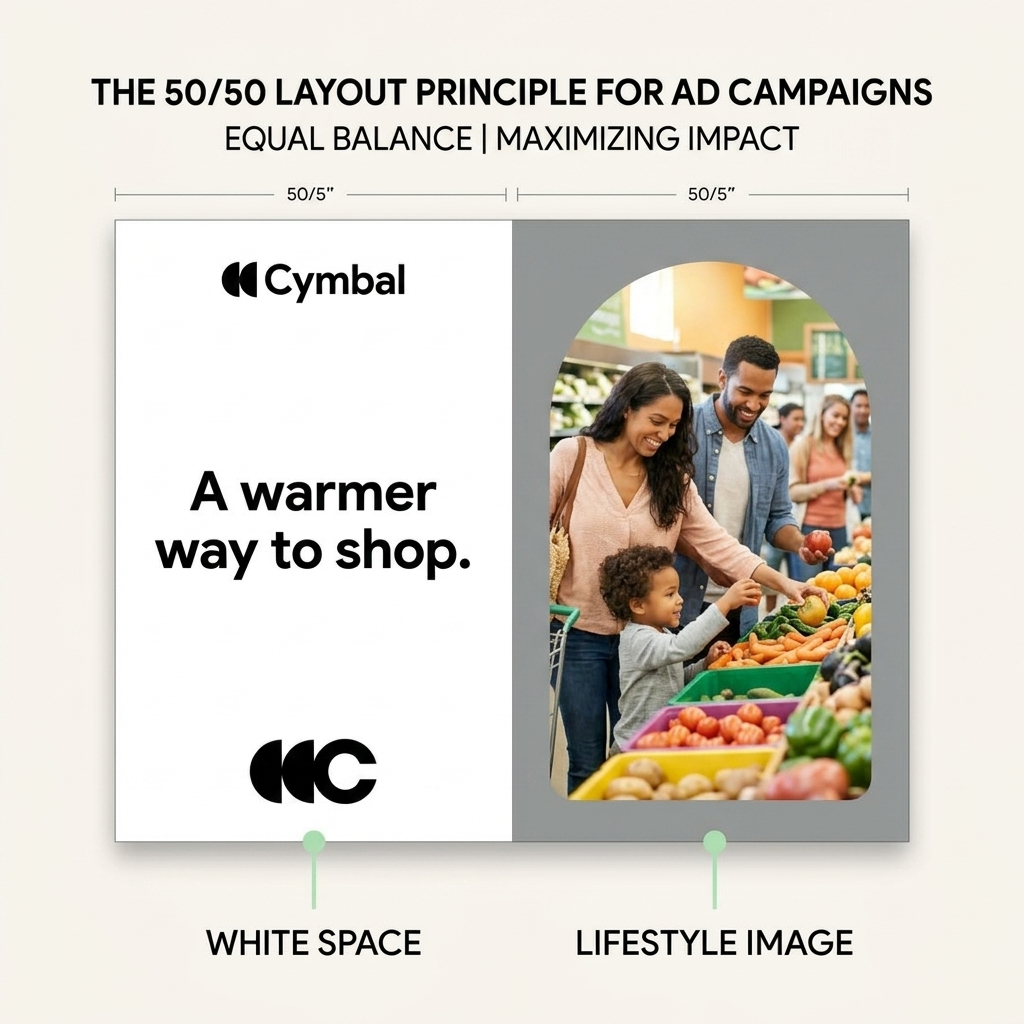

In [3]:
from PIL import Image
import urllib.request

# Load and display infographic from GitHub
url = "https://raw.githubusercontent.com/salekh/cloud-summit-dach-2026/main/infographics/layout_50_50_infographic.png"
img = Image.open(urllib.request.urlopen(url))
img


This follows the Cymbal layout guidelines: generous negative space on the left, vibrant photography masked inside the signature arch shape on the right.


In [ ]:
# Cell 3.2 — Define the full Cymbal Superstore campaign prompt

SUPERSTORE_CAMPAIGN_PROMPT = """
Please design a brand-adherent and compliant Digital Ad for Cymbal Superstore. 
Use the brand guidelines provided in the attached PDFs, as well as visual samples 
for brand style, identity and media samples.

Layout Concept: A minimalist 50/50 balance. The left side is airy and white 
(generous negative space) containing the clean typography and logo system. 
The right side features a vibrant lifestyle photograph masked inside Cymbal's 
signature graphic device—the arch shape.

Image Content (For the lifestyle photograph):
"An authentic, high-resolution lifestyle photograph of a diverse young family 
laughing together while selecting fresh organic produce at a modern, bright 
local supermarket. Warm ambient natural light streaming through large windows, 
creating a golden glow. The photograph has a distinct shallow depth of field, 
with the background softly blurred. The color grading features a rich, subtle 
warm red-and-peach tone bias, highlighting colorful red apples, warm wooden 
crates, and soft copper fixtures. The overall mood is approachable, warm, 
authentic, and human-centric. No corporate staging, highly naturalistic."

Ad Compositing & Layout Description:

Left Half (White Backdrop):
- Top Left: The Cymbal Superstore logo lockup (attached)
- Center: The slogan "A warmer way to shop." set in bold, black DM Sans 
  at a highly contrasting display size.
- Bottom Left: The Cymbal monogram (use the attached image) (attached) placed discretely in the 
  corner as a footer element.

Right Half: The generated lifestyle photograph is clipped inside a large 
vertical geometric arch/tombstone shape (flat top with sharp bottom corners) 
that bleeds elegantly off the right and bottom edges of the page.
"""

print(f"📝 Campaign prompt defined: {len(SUPERSTORE_CAMPAIGN_PROMPT):,} characters")
print(f"\n🔍 Key elements:")
print(f"   🏢 Brand: Cymbal Superstore")
print(f"   💬 Slogan: \"A warmer way to shop.\"")
print(f"   📐 Layout: 50/50 split with arch graphic device")
print(f"   📷 Photo: Diverse family in organic supermarket")

In [ ]:
# Cell 3.3 — Generate the Cymbal Superstore campaign image with Nano Banana 2

print("🎨 Generating Cymbal Superstore campaign with Nano Banana 2...")
print(f"   Model: {NANO_BANANA_MODEL}")
print(f"   Brand context: PDFs + 6 visual samples + Superstore logo + text guidelines")
print(f"   Prompt length: {len(SUPERSTORE_CAMPAIGN_PROMPT):,} chars")
print()

superstore_uri, superstore_image_data = generate_campaign_image(
    prompt=SUPERSTORE_CAMPAIGN_PROMPT,
    sub_brand="superstore",
    filename="campaign_superstore_original.png",
    title="🋒 Cymbal Superstore — \"A Warmer Way to Shop\"",
)

### 🔍 Analyzing the Output

**What to look for in a brand-adherent campaign:**

| Criterion | What to Check |
|-----------|---------------|
| ✅ **Logo placement** | Superstore lockup top-left, monogram bottom-left |
| ✅ **Typography** | DM Sans (not Arial, not Helvetica), bold weight for slogan |
| ✅ **Color adherence** | Red/terracotta palette, no off-brand colors |
| ✅ **Layout grid** | Clean 50/50 split, generous whitespace on left |
| ✅ **Arch device** | Photo masked in the signature arch shape |
| ✅ **Photography style** | Warm, diverse, naturalistic, shallow DOF |
| ✅ **Brand personality** | Approachable, warm, human-centric |

> 💡 **Prompt Engineering Tip:** The more specific your layout description, the better the result. Compare these two prompts:
>
> ❌ *"Make an ad for Cymbal Superstore"* — vague, could produce anything
>
> ✅ *"Minimalist 50/50 balance. Left side: airy white with logo top-left, slogan centered in bold DM Sans, monogram bottom-left. Right side: lifestyle photo in arch shape bleeding off edges."* — precise, compositionally aware
>
> The second prompt gives the model a **spatial blueprint**. Always describe layout in terms of spatial relationships, not just content.

---

## 🏦 Section 4: Campaign 2 — Cymbal Bank: LLM-Assisted Creative Ideation

In Campaign 1, we wrote the entire prompt by hand. That works great for a single ad — but what about scaling to **dozens of campaigns** across brands?

Here we introduce a **two-stage pipeline:**


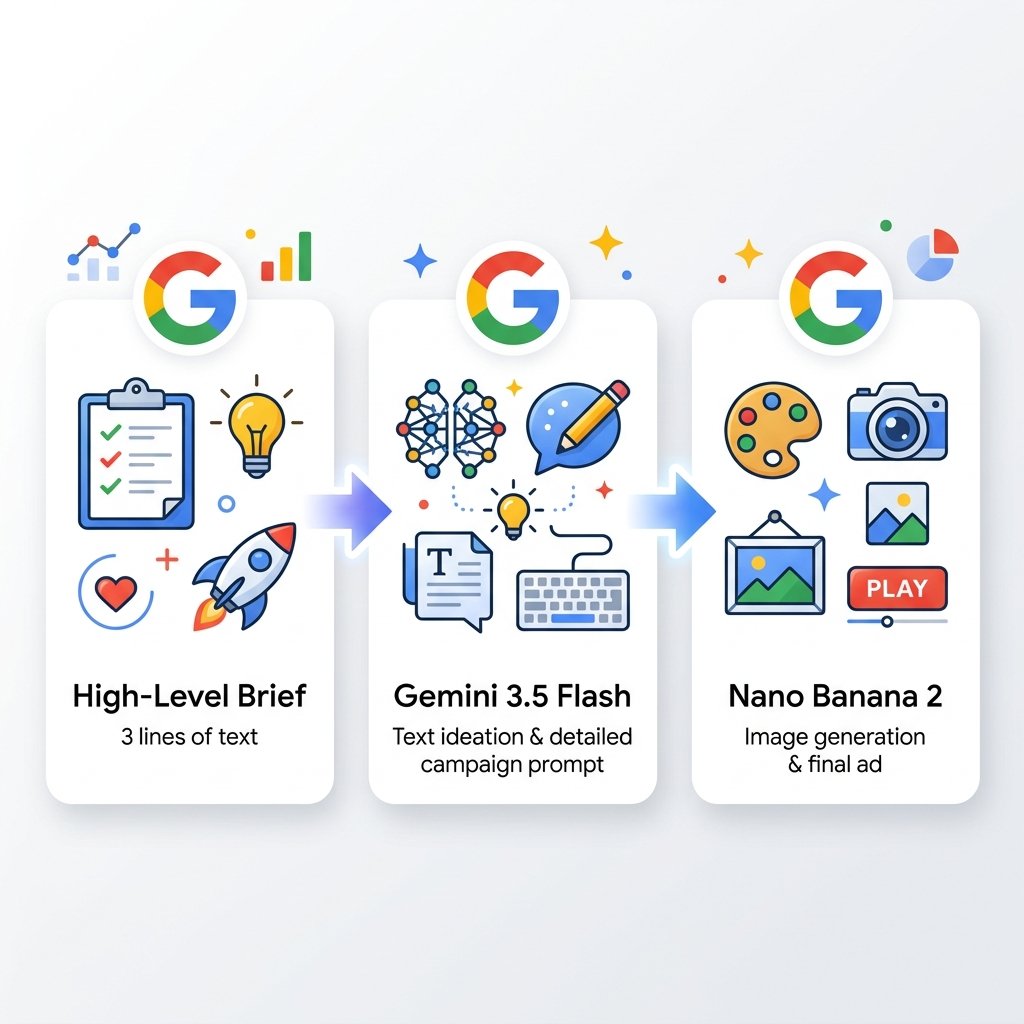

In [1]:
from PIL import Image
import urllib.request

# Load and display infographic from GitHub
url = "https://raw.githubusercontent.com/salekh/cloud-summit-dach-2026/main/infographics/campaign_pipeline_infographic.png"
img = Image.open(urllib.request.urlopen(url))
img


**Stage 1:** Give Gemini 3.5 Flash a brief + brand guidelines → it generates a detailed campaign prompt  
**Stage 2:** Feed that prompt into Nano Banana 2 → it generates the campaign image

This is **creative ideation at scale** — the LLM becomes your creative director.


In [ ]:
# Cell 4.2 — Stage 1: Use Gemini 3.5 Flash to generate a detailed campaign prompt from a brief

BANK_BRIEF = """
Create a premium digital ad campaign for Cymbal Bank.

Brand: Cymbal Bank (Financial Services & Insurance)
Slogan idea: "Navigate your future with confidence."
Target audience: Young professionals starting their investment journey
Mood: Trustworthy, modern, aspirational, yet approachable
Photography direction: A confident young professional in her late 20s
reviewing financial data on a sleek laptop in a modern, sunlit co-working
space. Warm natural light streaming through floor-to-ceiling windows.
Shallow depth of field, green-tinted color grading matching the FSI palette.
Plants and modern furniture visible in the soft-focus background.
The mood is calm, focused, and optimistic.
"""

IDEATION_SYSTEM_PROMPT = """
You are Cymbal's Senior Creative Director. Given a brief and the complete Cymbal
Brand Design Language, generate a detailed campaign prompt that an IMAGE GENERATION
MODEL will use to create the ad visual.

CRITICAL: Your output will be fed DIRECTLY into an image generation model.
Write it as a VISUAL CONSTRUCTION prompt, not a creative brief or description.
Be concrete, spatial, and directive — as if you are art-directing a compositor.

Your output MUST follow this EXACT structure (use the example below as a template):

---
Please design a brand-adherent and compliant Digital Ad for [Brand Name].
Use the brand guidelines provided in the attached PDFs, as well as visual samples
for brand style, identity and media samples.

Layout Concept: [Describe the spatial composition — e.g. "A minimalist 50/50
balance. Left side is airy white with typography. Right side features a lifestyle
photograph masked inside a geometric arch shape."]

Image Content (For the lifestyle photograph):
"[Detailed photographic description: subjects, ethnicity, age, clothing, setting,
lighting (natural/studio/golden hour), depth of field, color grading with brand
color tonal bias, mood. Be extremely specific — 4-6 sentences.]"

Ad Compositing & Layout Description:

Left Half (White Backdrop):
- Top Left: The [Brand] logo lockup (attached)
- Center: The slogan "[slogan]" set in bold, black DM Sans at display size.
- Sub-headline: "[supporting text]" in regular DM Sans, smaller size.
- Bottom Left: The Cymbal monogram (use the attached image) placed discretely.

Right Half: The lifestyle photograph clipped inside [geometric shape from brand
shape library] that bleeds off the right and bottom edges.
---

RULES:
- ALWAYS say "attached" when referring to logos and monograms (they are image inputs)
- NEVER describe logos textually — just say "The [Brand] logo lockup (attached)"
- Use the brand's sub-brand color family as tonal bias in the photograph
- Keep the prompt under 300 words — concise and spatial
- Follow the Cymbal Brand Design Language attached
"""

# Build the content with brand guidelines
ideation_parts = build_brand_context("bank")
ideation_parts.append(types.Part.from_text(text=f"""
{BANK_BRIEF}

Generate the detailed campaign prompt following the structure described in your instructions.
"""))

print("🧠 Stage 1: Generating detailed campaign prompt with Gemini 3.5 Flash...")
print(f"   Model: {GEMINI_FLASH_MODEL}")
print(f"   Brief: {len(BANK_BRIEF)} chars")
print()

ideation_response = client.models.generate_content(
    model=GEMINI_FLASH_MODEL,
    contents=types.Content(
        role="user",
        parts=ideation_parts
    ),
    config=types.GenerateContentConfig(
        system_instruction=IDEATION_SYSTEM_PROMPT,
        temperature=0.9,  # Higher creativity for ideation
    )
)

bank_campaign_prompt = ideation_response.text

print("✅ Campaign prompt generated!\n")
print("=" * 70)
IPydisplay.display(IPydisplay.Markdown(bank_campaign_prompt))
print("=" * 70)

In [ ]:
# Cell 4.3 — Stage 2: Feed the LLM-generated prompt into Nano Banana 2

print("🎨 Stage 2: Generating Cymbal Bank campaign image with Nano Banana 2...")
print(f"   Using the prompt generated by Gemini 3.5 Flash ({len(bank_campaign_prompt):,} chars)")
print()

bank_uri, bank_image_data = generate_campaign_image(
    prompt=bank_campaign_prompt,
    sub_brand="bank",
    filename="campaign_bank.png",
    title="🏦 Cymbal Bank — \"Navigate Your Future with Confidence\"",
)

### 💡 Best Practices: LLM-Assisted Creative Ideation

**Why chain two models?**

| Step | Model | Role | Analogy |
|------|-------|------|---------|
| **Ideation** | Gemini 3.5 Flash (text) | Creative Director | Writes the creative brief |
| **Generation** | Nano Banana 2 (image) | Photographer/Designer | Executes the vision |

**Key advantages of this pipeline:**

1. **Scalability** — Generate 100 campaign variants from 100 one-line briefs
2. **Auditability** — The intermediate prompt is human-readable; you can review and edit before generation
3. **Consistency** — The system prompt enforces brand-adherent output every time
4. **Creativity** — Higher temperature (0.9) in the ideation stage encourages novel concepts while staying on-brand

> 💡 **Pro tip:** Use structured output (JSON schema) for the ideation step in production. This gives you programmatic access to layout specs, color codes, and copy — enabling automated QA checks before image generation.

---

## 💊 Section 5: Campaign 3 — Cymbal Health: Your Turn!

Now it's your turn to drive the creative process. We'll use the same two-stage pipeline, but **you write the brief**.

### Cymbal Health — Brand Quick Reference

| Property | Value |
|----------|-------|
| **Industry** | Healthcare & Life Sciences (HCLS) |
| **Primary Color** | Blue family |
| **Logo Colors** | Dark navy (`#1B2A4A`), Silver gray (`#B0B8C0`), Slate blue-grey (`#5C6B7A`), Deep royal blue (`#1A3A8F`) |
| **Logo Shape** | Cross/plus shape from 4 rounded rectangular pill shapes, circle at top center |
| **Photography** | Lab workers, medical procedures, DNA/molecular imagery — blue tonal bias |
| **Brand Personality** | Caring, trustworthy, scientifically grounded, human |

### Suggested Themes (pick one or invent your own!)

- 💙 *"Caring beyond medicine"* — Focus on holistic health and wellness
- 💓 *"Your health, our heartbeat"* — Emphasize the human side of healthcare
- 🧬 *"Science in service of life"* — Innovation + humanity
- 🌟 *"Every patient, a priority"* — Personalized care

In [ ]:
# Cell 5.2 — ✈️ YOUR BRIEF HERE — Write your Cymbal Health campaign brief!
# 
# Edit the brief below and run this cell. Gemini 3.5 Flash will expand it
# into a detailed campaign prompt, then Nano Banana 2 will generate the ad.
#
# Tips:
#   - Keep it concise (3-5 lines is perfect)
#   - Mention the target audience and mood
#   - Suggest a photography direction
#   - Include a slogan idea

HEALTH_BRIEF = """
Create a premium digital ad campaign for Cymbal Health.

Brand: Cymbal Health (Healthcare & Life Sciences)
Logo: Cross/plus shape from 4 rounded pills with circle at top — navy/blue palette
Slogan idea: "Your health, our heartbeat."
Target audience: Health-conscious families choosing a modern healthcare provider
Mood: Caring, warm, scientifically credible, yet deeply human
Photography direction: A compassionate doctor in a bright modern clinic, 
smiling while reviewing results with a young mother holding a cheerful toddler.
The setting should feel warm and state-of-the-art, not clinical or cold.
"""

In [ ]:
# Cell 5.3 — Stage 1: Expand the brief with Gemini 3.5 Flash

health_ideation_parts = build_brand_context("health")
health_ideation_parts.append(types.Part.from_text(text=f"""
{HEALTH_BRIEF}

Generate the detailed campaign prompt following the structure described in your instructions.
Remember: Cymbal Health uses the BLUE color family. Follow the HCLS photography guidelines.
"""))

print("🧠 Stage 1: Expanding your brief with Gemini 3.5 Flash...")

health_ideation_response = client.models.generate_content(
    model=GEMINI_FLASH_MODEL,
    contents=types.Content(
        role="user",
        parts=health_ideation_parts
    ),
    config=types.GenerateContentConfig(
        system_instruction=IDEATION_SYSTEM_PROMPT,
        temperature=1.0,
    )
)

health_campaign_prompt = health_ideation_response.text

print("✅ Campaign prompt generated!\n")
IPydisplay.display(IPydisplay.Markdown(health_campaign_prompt))

In [ ]:
# Cell 5.4 — Stage 2: Generate the campaign image

print("🎨 Stage 2: Generating Cymbal Health campaign with Nano Banana 2...")

health_uri, health_image_data = generate_campaign_image(
    prompt=health_campaign_prompt,
    sub_brand="health",
    filename="campaign_health.png",
    title="💊 Cymbal Health — \"Your Health, Our Heartbeat\"",
)

---

## 🌍 Section 6: Localization at Scale — Taking Cymbal to Germany

You've generated campaigns for the global market. Now let's **localize** one for the **German-speaking DACH region** (Deutschland, Österreich, Schweiz).

Localization isn't just translation. It's a **three-layer transformation:**

| Layer | What Changes | Example |
|-------|-------------|----------|
| 📝 **Linguistic** | Slogans, body copy, legal disclaimers | "A warmer way to shop" → "Die wärmere Art einzukaufen" |
| 📷 **Visual/Cultural** | Photography subjects, settings, products, signage | Generic supermarket → German Bio-Markt with Handwerksbrot |
| 📋 **Regulatory** | Disclaimers, data privacy notices, accessibility | DSGVO compliance, German advertising regulations |

### Our Approach

We'll take the Cymbal Superstore campaign we generated earlier and:
1. Use **Gemini 3.5 Flash** to generate a comprehensive localization brief
2. Use **Nano Banana 2** to generate the localized visual with culturally adapted imagery
3. Compare the original and localized versions side-by-side

> 🎯 **Key insight:** With generative media, localization becomes a **prompt transformation** problem, not a manual redesign. One campaign, 50 markets, minutes not months.

In [ ]:
# Select the campaign to localize
#
# We'll use the Cymbal Superstore campaign from Section 3.
# You can change this to any of the generated campaigns:
#   - superstore_uri / superstore_image_data
#   - bank_uri / bank_image_data  
#   - health_uri / health_image_data

source_campaign_uri = superstore_uri
source_campaign_data = superstore_image_data
source_sub_brand = "superstore"
source_slogan = "A warmer way to shop."

print(f"🎯 Selected campaign for localization:")
print(f"   Brand:  Cymbal Superstore")
print(f"   Slogan: \"{source_slogan}\"")
print(f"   Source: {source_campaign_uri}")
print()

# Display the source campaign
IPydisplay.display(IPydisplay.Markdown("### Original Campaign (Global/English)"))
img = Image.open(io.BytesIO(source_campaign_data))
IPydisplay.display(img)


In [ ]:
# Cell 6.3 — Use Gemini 3.5 Flash to generate a localization brief

LOCALIZATION_SYSTEM_PROMPT = """
You are a Senior Localization Strategist specializing in the German-speaking
DACH market (Deutschland, Österreich, Schweiz). Given an original English
campaign and the Cymbal Brand Design Language, generate a localized campaign
prompt that an IMAGE GENERATION MODEL will use to create the localized ad.

CRITICAL: Your output will be fed DIRECTLY into an image generation model.
Write it as a VISUAL CONSTRUCTION prompt, not a localization strategy document.
Be concrete, spatial, and directive.

Your output MUST follow this EXACT structure:

---
Please design a brand-adherent Digital Ad for [Brand], localized for the
German (DACH) market. Use the brand guidelines and visual samples attached.
This is a LOCALIZATION of the attached original campaign image.

Layout Concept: [Keep the same spatial structure as the original — describe
the 50/50 split, arch shape, etc. Maintain brand identity.]

Image Content (Localized photograph):
"[Adapt the photography for German cultural context: specific setting
(e.g. Bio-Markt, Wochenmarkt), subjects, products (Handwerksbrot, regional
produce), lighting, color grading with brand tonal bias. 4-6 sentences.]"

Ad Compositing & Layout Description:

Left Half (White Backdrop):
- Top Left: The [Brand] logo lockup (attached)
- Center: German headline "[localized slogan]" in bold, black DM Sans, display size.
- Sub-headline: "[German supporting text]" in regular DM Sans, smaller size.
- Bottom Left: The Cymbal monogram (use the attached image) placed discretely.

Right Half: Localized lifestyle photograph clipped inside [same geometric
shape as original] bleeding off the right and bottom edges.
---

DACH CULTURAL RULES:
- Quality and craftsmanship (Handwerksqualität) resonate deeply
- Regional sourcing is valued ("aus der Region", Bio, Nachhaltigkeit)
- German consumers prefer understatement over hyperbole
- Use formal "Sie" form, not "du"
- Keep prompt under 300 words — concise and spatial
- ALWAYS say "attached" for logos and monograms
- NEVER describe logos textually
"""

localization_parts = build_brand_context(source_sub_brand)
localization_parts.append(types.Part.from_text(text=f"""
Original Campaign Details:
- Brand: Cymbal Superstore
- Original Slogan: "{source_slogan}"
- Original Photography: Diverse family in modern supermarket, warm natural light, 
  shallow DOF, red-peach tonal bias
- Original Layout: 50/50 split, white left panel with logo + slogan, 
  right panel with photo in arch shape

Target Market: Germany (DACH region)
Generate a comprehensive localization brief for the German market.
"""))

print("🌍 Generating localization brief with Gemini 3.5 Flash...")

localization_response = client.models.generate_content(
    model=GEMINI_FLASH_MODEL,
    contents=types.Content(
        role="user",
        parts=localization_parts
    ),
    config=types.GenerateContentConfig(
        system_instruction=LOCALIZATION_SYSTEM_PROMPT,
        temperature=0.7,  # Slightly lower for translation accuracy
    )
)

localization_brief = localization_response.text

print("✅ Localization brief generated!\n")
IPydisplay.display(IPydisplay.Markdown(localization_brief))

In [ ]:
# Cell 6.4 — Use the localization brief directly as the campaign prompt
#
# The localization system prompt already generates output in the correct
# image-generation-ready format, so we use it directly.

GERMAN_CAMPAIGN_PROMPT = localization_brief

print(f"📝 Localized campaign prompt: {len(GERMAN_CAMPAIGN_PROMPT):,} characters")
print(f"   Market: Germany (DACH)")


In [ ]:
# Cell 6.5 — Generate the localized German campaign with Nano Banana 2
#
# We pass the ORIGINAL campaign image as input — the model uses it as a 
# visual reference to maintain layout consistency while adapting content.

print("🌍 Generating localized German campaign with Nano Banana 2...")
print(f"   Model: {NANO_BANANA_MODEL}")
print(f"   Input image: {source_campaign_uri}")
print(f"   Adaptations: German text, Bio-Markt photography, DACH cultural details")
print()

german_uri, german_image_data = generate_campaign_image(
    prompt=GERMAN_CAMPAIGN_PROMPT,
    sub_brand="superstore",
    filename="campaign_superstore_de.png",
    title="🇩🇪 Cymbal Superstore — Deutsche Lokalisierung",
    input_image_uri=source_campaign_uri,
)

In [ ]:
# Side-by-side comparison: Original vs. Localized

def display_side_by_side(img_data_1: bytes, label_1: str, img_data_2: bytes, label_2: str):
    """Display two images side-by-side with labels. Colab-native rendering."""
    img1 = Image.open(io.BytesIO(img_data_1))
    img2 = Image.open(io.BytesIO(img_data_2))
    
    # Resize to same height for fair comparison
    target_height = 600
    
    ratio1 = target_height / img1.height
    img1_resized = img1.resize((int(img1.width * ratio1), target_height), Image.LANCZOS)
    
    ratio2 = target_height / img2.height
    img2_resized = img2.resize((int(img2.width * ratio2), target_height), Image.LANCZOS)
    
    # Create side-by-side canvas
    gap = 40
    total_width = img1_resized.width + gap + img2_resized.width
    canvas = Image.new("RGB", (total_width, target_height + 50), (255, 255, 255))
    
    # Paste images
    canvas.paste(img1_resized, (0, 50))
    canvas.paste(img2_resized, (img1_resized.width + gap, 50))
    
    IPydisplay.display(IPydisplay.Markdown(f"### 🔀 Comparison: {label_1} vs. {label_2}"))
    # PIL images render natively in Colab Enterprise
    IPydisplay.display(canvas)

if source_campaign_data and german_image_data:
    display_side_by_side(
        source_campaign_data, "🇬🇧 Original (Global/English)",
        german_image_data, "🇩🇪 Localized (German/DACH)"
    )
else:
    print("⚠️ One or both campaign images are not available for comparison.")


### 🌐 Scaling Localization: From 1 Market to 50

What we just demonstrated for Germany can be automated across **any market**:

```python
# Production localization pipeline (pseudocode)
markets = [
    {"code": "de", "name": "Germany", "language": "German", "culture_notes": "Bio-Markt, Handwerksqualität..."},
    {"code": "fr", "name": "France", "language": "French", "culture_notes": "Marché bio, terroir..."},
    {"code": "jp", "name": "Japan", "language": "Japanese", "culture_notes": "Konbini, seasonal themes..."},
    # ... 47 more markets
]

for market in markets:
    brief = generate_localization_brief(original_campaign, market)  # Stage 1
    localized_ad = generate_campaign_image(brief, market)            # Stage 2
    save_to_dam(localized_ad, market)                                # Digital Asset Mgmt
```

**Time comparison:**

| Approach | Time for 50 Markets | Cost |
|----------|--------------------:|------|
| Traditional agency | 6–12 months | $$$$$ |
| In-house design team | 3–6 months | $$$$ |
| GenAI pipeline (what we built) | **~2 hours** | $ |

> 💡 **Production tip:** Add a **human-in-the-loop review** step between generation and deployment. Generative media is a draft accelerator, not a replace-all. The best pipelines combine AI speed with human judgment.

---

## 🌟 Section 7: What We Built — The GenMedia Production Pipeline

### Recap

In this session, we built a complete **brand-adherent content generation pipeline**:

| Step | What We Did | Key Technique |
|------|------------|---------------|
| ✅ **Brand DNA Ingestion** | Fed complete brand guidelines (PDF + text + visual samples) into the model | Multimodal brand context |
| ✅ **Guided Campaign** | Generated a Cymbal Superstore ad with hand-crafted prompts | Spatial layout description |
| ✅ **LLM-Assisted Ideation** | Used Gemini 3.5 Flash to expand briefs into detailed prompts | Two-stage prompt chaining |
| ✅ **Interactive Campaign** | Generated a Cymbal Health ad from a user-written brief | Template-driven generation |
| ✅ **Localization** | Adapted a campaign for the German DACH market | Cultural + linguistic transformation |

### The Pipeline Architecture


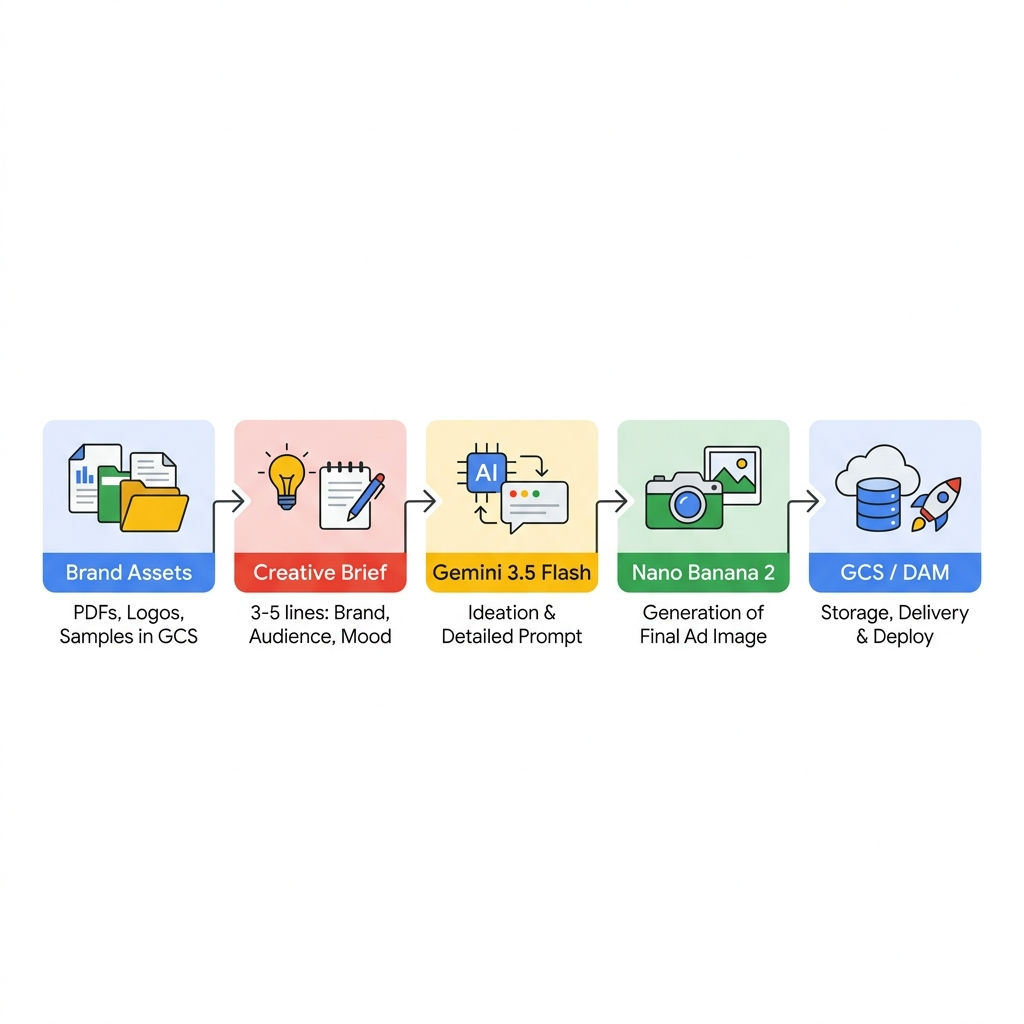

In [2]:
from PIL import Image
import urllib.request

# Load and display infographic from GitHub
url = "https://raw.githubusercontent.com/salekh/cloud-summit-dach-2026/main/infographics/pipeline_architecture_infographic.png"
img = Image.open(urllib.request.urlopen(url))
img


### 🚀 What's Next: The Future of GenMedia in Marketing

| Capability | Technology | Status |
|-----------|-----------|--------|
| 🎥 **Brand video generation** | Veo | Generate 15-30s brand videos from campaign stills |
| 🧪 **A/B testing at scale** | Nano Banana 2 + Analytics | Generate 50 variants, test with real audiences |
| 🛡️ **Automated brand compliance** | Gemini 3.5 Flash | LLM-based QA: "Does this ad follow the brand guide?" |
| 🔄 **Feedback loops** | Gemini + Marketing APIs | Campaign performance data feeds back into prompt optimization |
| 🤝 **Marketing platform integration** | Cloud Functions + APIs | Direct publish to Google Ads, Meta, TikTok |

### 📚 Key Takeaways

1. **Brand guidelines are your most valuable AI input.** The richer and more structured your brand DNA, the better the output.
2. **Two-stage pipelines unlock scale.** LLM ideation + image generation = hundreds of on-brand campaigns from simple briefs.
3. **Localization is a prompt transformation.** Cultural adaptation becomes minutes, not months.
4. **Human judgment stays central.** Generative media accelerates drafts; humans validate and refine.
5. **GCS is your content backbone.** Centralized brand assets + generated outputs = reproducible, auditable pipelines.

---

### 🙏 Thank You!

**Questions?** Let's discuss!

*Built with ❤️ using Nano Banana 2 and Gemini 3.5 Flash on Google Cloud.*